# Build `recife_fin.csv` from raw Recife database

This notebook cleans, translates, preprocesses, and feature-engineers `recife-db.csv` into a `single_type.csv`-style file.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
import os
from dotenv import load_dotenv

load_dotenv()
RECIFE_PATH = Path(os.getenv("RECIFE_PATH"))
OUTPUT_PATH = Path("recife_fin.csv")

# minimum available rows in a column
M_THRESHOLD = 0.28

In [50]:
SYMPTOM_OR_RISK_RAW = [
    "febre", "mialgia", "cefaleia", "exantema",
    "vomito", "nausea", "dor_costas", "conjutivite",
    "artrite", "artralgia", "petequia_n", "leucopenia",
    "laco", "dor_retro", "diabetes", "hematolog",
    "hepatopat", "renal", "hipertensao", "acido_pept",
    "auto_imune"
]

RENAME_MAP = {
    "nu_notificacao": "notification_id",
    "tp_notificacao": "notification_type",
    "co_cid": "disease_code",
    "dt_notificacao": "notification_date",
    "ds_semana_notificacao": "notification_epiweek",
    "notificacao_ano": "notification_year",
    "co_uf_notificacao": "notification_state",
    "co_municipio_notificacao": "notification_municipality",
    "id_regional": "notification_regional",
    "co_unidade_notificacao": "notification_unit",
    "dt_diagnostico_sintoma": "first_symptom_date",
    "ds_semana_sintoma": "first_symptom_epiweek",
    "dt_nascimento": "DoB", # DoB
    "nu_idade": "age_code",
    "tp_sexo": "sex",
    "tp_gestante": "pregnancy_status",
    "tp_raca_cor": "race",
    "co_uf_residencia": "residence_state",
    "co_municipio_residencia": "residence_municipality",
    "co_regional_residencia": "residence_regional",
    "co_bairro_residencia": "residence_neighborhood_code",
    "no_bairro_residencia": "residence_neighborhood_name",
    "tp_zona_residencia": "residence_zone",
    "co_pais_residencia": "residence_country",
    "dt_investigacao": "investigation_date",
    "febre": "fever",
    "mialgia": "myalgia",
    "cefaleia": "headache",
    "exantema": "rash",
    "vomito": "vomiting",
    "nausea": "nausea",
    "dor_costas": "back_pain",
    "conjutivite": "conjunctivitis",
    "artrite": "arthritis",
    "artralgia": "arthralgia",
    "petequia_n": "petechiae",
    "leucopenia": "leukopenia",
    "laco": "tourniquet_test",
    "dor_retro": "retroorbital_pain",
    "diabetes": "diabetes",
    "hematolog": "hematologic_disease",
    "hepatopat": "liver_disease",
    "renal": "kidney_disease",
    "hipertensao": "hypertension",
    "acido_pept": "peptic_acid_disease",
    "auto_imune": "autoimmune_disease",
    "tp_classificacao_final": "final_classification_code",
    "tp_criterio_confirmacao": "confirmation_criterion_code",
    "dt_encerramento": "closure_date",
}

SYMPTOM_FEATURES = [
    "fever", "myalgia", "headache", "rash", "vomiting", "nausea",
    "back_pain", "conjunctivitis", "arthritis", "arthralgia",
    "petechiae", "retroorbital_pain"
]

RISK_FEATURES = [
    "diabetes", "hematologic_disease", "liver_disease", "kidney_disease",
    "hypertension", "peptic_acid_disease", "autoimmune_disease"
]

BI_FEATURES = SYMPTOM_FEATURES + RISK_FEATURES

YES_NO_MAP = {
    "1": 1, "1.0": 1, 1: 1, 1.0: 1,
    "2": 0, "2.0": 0, 2: 0, 2.0: 0,
    "9": np.nan, "9.0": np.nan, 9: np.nan, 9.0: np.nan,
    "": np.nan,
    "Yes": 1, "No": 0,
    "YES": 1, "NO": 0,
    "Sim": 1, "Não": 0, "Nao": 0,
    "SIM": 1, "NAO": 0,
}

NOTIFICATION_TYPE_MAP = {
    "1": "Negative", "1.0": "Negative",
    "2": "Individual", "2.0": "Individual",
    "3": "Outbreak", "3.0": "Outbreak",
    "4": "Aggregated", "4.0": "Aggregated",
}

SEX_MAP = {"M": "Male", "F": "Female", "I": "Unknown"}

PREGNANCY_MAP = {
    "1": "1st trimester", "1.0": "1st trimester",
    "2": "2nd trimester", "2.0": "2nd trimester",
    "3": "3rd trimester", "3.0": "3rd trimester",
    "4": "Gestational age unknown", "4.0": "Gestational age unknown",
    "5": "No", "5.0": "No",
    "6": "Not applicable", "6.0": "Not applicable",
    "9": "Unknown", "9.0": "Unknown",
}

RACE_MAP = {
    "1": "White", "1.0": "White",
    "2": "Black", "2.0": "Black",
    "3": "Asian", "3.0": "Asian",
    "4": "Brown", "4.0": "Brown",
    "5": "Indigenous", "5.0": "Indigenous",
    "9": "Unknown", "9.0": "Unknown",
}

ZONE_MAP = {
    "1": "Urban", "1.0": "Urban",
    "2": "Rural", "2.0": "Rural",
    "3": "Peri-urban", "3.0": "Peri-urban",
    "9": "Unknown", "9.0": "Unknown",
}

CONFIRMATION_MAP = {
    "1": "Laboratory", "1.0": "Laboratory",
    "2": "Clinical-epidemiological", "2.0": "Clinical-epidemiological",
    "3": "Under investigation", "3.0": "Under investigation",
    "5": "Other / unknown", "5.0": "Other / unknown",
}

FINAL_CLASS_MAP = {
    "1": "Confirmed", "1.0": "Confirmed",
    "2": "Discarded", "2.0": "Discarded",
    "5": "Discarded", "5.0": "Discarded",
    "8": "Inconclusive", "8.0": "Inconclusive",
    "10": "Dengue", "10.0": "Dengue",
    "11": "Dengue with warning signs", "11.0": "Dengue with warning signs",
    "12": "Severe dengue", "12.0": "Severe dengue",
    "13": "Chikungunya", "13.0": "Chikungunya",
}


# Helper functions
## normalize func:
## boolean agreament:
Convert to 1 and 0
## Age converter
Age is decoded in hours, days, months and years in the original dataset -> transform to year.

## Clinical time-window categories
Sort them by days
- `very early`: 0-1
- `early acute`: 2-3
- `mid-acute`: 4-5
- `late acute first-week illness`: 6-7
- `subacute / persistent symptoms`: 8-14
- `prolonged illness`: 15-21
- `very prolonged illness`: 22+
#### based on dengue clinical-phase timing from WHO/CDC-style clinical guidance

## Targets with severity (for future expansion if possible)
Vision: know Dengue or not Dengue, if Dengue then goes deeper to severity

In [51]:
## Normalize val
def normalize_code_value(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

## Boolean agreement
def convert_yes_no(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    return YES_NO_MAP.get(x, YES_NO_MAP.get(s, np.nan))

## Age converter
def age_decoder(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    m = re.match(r"^(\d)(\d+)$", s)
    if not m:
        return np.nan
    unit = int(m.group(1))
    value = int(m.group(2))
    if unit == 1: # hours
        return value / (24 * 365.25)
    if unit == 2: # days
        return value / 365.25
    if unit == 3: # months
        return value / 12
    if unit == 4:
        return float(value)

## clinical time-window categorization
def bin_days(series):
    s = pd.to_numeric(series, errors="coerce")
    out = pd.Series(pd.NA, index=s.index, dtype="object")
    out[s < 0] = "negative"
    out[(s >= 0) & (s <= 1)] = "0-1"
    out[(s >= 2) & (s <= 3)] = "2-3"
    out[(s >= 4) & (s <= 5)] = "4-5"
    out[(s >= 6) & (s <= 7)] = "6-7"
    out[(s >= 8) & (s <= 14)] = "8-14"
    out[(s >= 15) & (s <= 21)] = "15-21"
    out[s >= 22] = "22+"
    return out

## Outputs
def map_target_with_severity(x):
    x = normalize_code_value(x)
    if x == "10":
        return "Dengue mild"
    if x == "11":
        return "Dengue warning"
    if x == "12":
        return "Dengue severe"
    if x == "13":
        return "Chikungunya"
    if x in {"1", "2", "5", "8"}:
        return "Other"
    return pd.NA

# Main processing pipeline
## Clean
- Any symptoms or risk NaN in any row -> removed.
- Removed columns with more than 28% missing.
* Note: for pandas, `int64` cannot handle NaN values. If a col has NaN, pd will "upcast" the col to `float64` -> ❌; `Int64` store both int and pd.NA without converting the data to floats.
## Feature Engineering
- Phase windows
- Bin age group (infant, young child, and elderly).
- Rainy season (March to August) **Based on Recife, Pernambuco, Brazil** -> later must take account into VN seasons.
## Preprocess
- Fill any Risk Features NaN with 0.

In [52]:
df = pd.read_csv(RECIFE_PATH, low_memory=False) 
# low_memo=False means read whole file, = True means read by chunks divided by rows
# reason: incase different rows of same columns have different type of data (for example, number/bool and strings)

df = df.replace(r"^\s*$", pd.NA, regex=True)
for c in ["Unnamed: 0", "index"]:
    if c in df.columns:
        df = df.drop(columns=[c])

existing_filter_cols = [c for c in SYMPTOM_OR_RISK_RAW if c in df.columns]
df = df.dropna(subset=existing_filter_cols, how="all").copy()
missing_rate = df.isna().mean().sort_values(ascending=False)
cols_del = missing_rate[missing_rate >= M_THRESHOLD].index.tolist()
df = df.drop(columns=cols_del).copy()

df = df.rename(columns={k: v for k, v in RENAME_MAP.items() if k in df.columns})

# Boolean matching
for c in BI_FEATURES:
    if c in df.columns:
        df[c] = df[c].map(convert_yes_no).astype("Float64")

# Mapping
if "notification_type" in df.columns:
    df["notification_type"] = df["notification_type"].astype("string").map(NOTIFICATION_TYPE_MAP)
df["sex"] = df["sex"].astype("string").map(SEX_MAP)
df["pregnancy_status"] = df["pregnancy_status"].astype("string").map(PREGNANCY_MAP)
df["race"] = df["race"].astype("string").map(RACE_MAP)
df["residence_zone"] = df["residence_zone"].astype("string").map(ZONE_MAP)
df["age"] = df["age_code"].apply(age_decoder)
for c in ["notification_date", "first_symptom_date", "investigation_date", "DoB", "closure_date"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True)

df["sign_to_note"] = (df["notification_date"] - df["first_symptom_date"]).dt.days
df["note_bin"] = bin_days(df["sign_to_note"])
df["early_contact"] = df["sign_to_note"].between(0, 3, inclusive="both").astype("Int64")
df["acute_window"] = df["sign_to_note"].between(0, 7, inclusive="both").astype("Int64")
df["warning_window"] = df["sign_to_note"].between(3, 7, inclusive="both").astype("Int64")
df["subacute_window"] = df["sign_to_note"].between(8, 14, inclusive="both").astype("Int64")
df["persistent_over_14d"] = (df["sign_to_note"] > 14).astype("Int64")

df["sign_to_proper_care"] = (df["investigation_date"] - df["first_symptom_date"]).dt.days
df["proper_care_bin"] = bin_days(df["sign_to_proper_care"])
df["note_to_proper_care"] = (df["investigation_date"] - df["notification_date"]).dt.days

# Mark date the first symptom happen
df["onset_month"] = df["first_symptom_date"].dt.month.astype('Int64')
df["onset_weekofyear"] = df["first_symptom_date"].dt.isocalendar().week.astype('Int64')
df["onset_dayofyear"] = df["first_symptom_date"].dt.dayofyear.astype('Int64')
df["onset_quarter"] = df["first_symptom_date"].dt.quarter.astype('Int64')
df["in_rainy_season"] = df["onset_month"].isin([3, 4, 5, 6, 7, 8]).astype("Int64")

df["onset_month_sin"] = np.sin(df["onset_month"] * np.pi / 12)
df["onset_weekofyear_sin"] = np.sin(df["onset_weekofyear"] * np.pi / 53)
df["onset_dayofyear_sin"] = np.sin(df["onset_dayofyear"] * np.pi / 347)
df["onset_quarter_sin"] = np.sin(df["onset_quarter"] * np.pi / 4)

df["flag_notif_before_onset"] = (df.get("sign_to_note", pd.Series(np.nan, index=df.index)) < 0).astype('Int64')
df["flag_invest_before_onset"] = (df.get("sign_to_proper_care", pd.Series(np.nan, index=df.index)) < 0).astype('Int64')
df["flag_invest_before_notif"] = (df.get("note_to_proper_care", pd.Series(np.nan, index=df.index)) < 0).astype('Int64')
df["flag_negative_timeline_any"] = (
    (df["flag_notif_before_onset"] == 1) |
    (df["flag_invest_before_onset"] == 1) |
    (df["flag_invest_before_notif"] == 1)
).astype('Int64')

## Age group
df["infant_flag"] = (df["age"] < 1).astype('Int64')
df["young_child_flag"] = ((df["age"] >= 1) & (df["age"] < 5)).astype('Int64')
df["old_flag"] = (df["age"] >= 60).astype('Int64')
df["high_risk_age"] = (
    (df["infant_flag"] == 1) |
    (df["young_child_flag"] == 1) |
    (df["old_flag"] == 1)
).astype('Int64')

In [53]:
# Fill
risk = [c for c in RISK_FEATURES if c in df.columns]
df['comorbidity_count'] = df[risk].fillna(0).sum(axis=1)
df["has_chronic_risk"] = (df["comorbidity_count"] > 0).astype("Int64")
df["joint_score"] = df[["myalgia", "back_pain", "arthritis", "arthralgia"]].sum(axis=1)
df["gi_score"] = (
    df["nausea"] + 
    2 * df["vomiting"] + 
    0.75 * df["peptic_acid_disease"] + 
    0.25 * df[["kidney_disease", "liver_disease"]].sum(axis=1)
)

df["dengue_triad"] = df[["fever", "headache", "myalgia", "retroorbital_pain"]].sum(axis=1)
df["dengue_warning_triad"] = df[["warning_window", "gi_score", "petechiae", "retroorbital_pain"]].sum(axis=1)
df["chik_triad"] = df["fever"] + 2 * df[["rash", "conjunctivitis"]].max(axis=1)
df["total_symptom_burden"] = df[SYMPTOM_FEATURES + RISK_FEATURES].sum(axis=1)
df["joint_gi_ratio"] = df["joint_score"] / (df["gi_score"] + 1)
df["dengue_warning_time_x_petechiae"] = df["warning_window"] * df["petechiae"]
df["age_x_arthritis"] = df["age"] * df["arthritis"]

score = 0
for c in ["vomiting", "petechiae", "high_risk_age", "has_chronic_risk"]:
    if c in df.columns:
        score = score + df[c].fillna(0)
df["severe_warning"] = score

df = df.dropna(subset="final_classification_code")
df["final_classification_code"] = df["final_classification_code"].map(normalize_code_value).astype("string")
df["target_with_severity"] = df["final_classification_code"].apply(map_target_with_severity).astype("string")
df["target"] = df["target_with_severity"].replace({
    "Dengue warning": "Dengue severe_or_warning",
    "Dengue severe": "Dengue severe_or_warning",
}).astype("string")

df = df.reset_index()
df.head()

,index,notification_id,notification_type,disease_code,notification_date,notification_epiweek,notification_year,notification_state,notification_municipality,notification_regional,...,dengue_triad,dengue_warning_triad,chik_triad,total_symptom_burden,joint_gi_ratio,dengue_warning_time_x_petechiae,age_x_arthritis,severe_warning,target_with_severity,target
0,0,2126258,Individual,A90,2015-10-12,201549.0,2015.0,26.0,261160.0,1497.0,...,2.0,3.0,1.0,3.0,0.0,0.0,0.0,2.0,Other,Other
1,100,1887726,Individual,A90,2015-07-01,201501.0,2015.0,26.0,261160.0,1497.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Dengue mild,Dengue mild
2,287,1911050,Individual,A90,2015-12-01,201502.0,2015.0,26.0,261160.0,1497.0,...,3.0,0.0,1.0,3.0,1.0,0.0,0.0,0.0,Other,Other
3,300,1880272,Individual,A90,NaT,201503.0,2015.0,26.0,260790.0,1497.0,...,3.0,0.0,1.0,3.0,1.0,0.0,0.0,0.0,Dengue mild,Dengue mild
4,309,1911044,Individual,A90,2015-12-01,201502.0,2015.0,26.0,261160.0,1497.0,...,3.0,0.0,1.0,3.0,1.0,0.0,0.0,0.0,Dengue mild,Dengue mild


# Cleaning

In [54]:
col_del = ["onset_month", "onset_dayofyear" , "onset_weekofyear", "onset_quarter",
           "notification_id", 'notification_type', 'disease_code', 'notification_date',
           'notification_epiweek', 'notification_year', 'notification_state', 'notification_municipality',
           'notification_regional', 'notification_unit', 'tp_escolaridade', 'residence_state', 'residence_municipality',
           'residence_regional', 'co_distrito_residencia', 'residence_neighborhood_code', 'residence_neighborhood_name',
           'nome_logradouro_residencia', 'residence_zone', 'residence_country', 'investigation_date', 'leukopenia', 
           'tourniquet_test', 'final_classification_code', 'confirmation_criterion_code', 'tp_evolucao_caso', 'age_code',
           'closure_date', 'first_symptom_epiweek', 'first_symptom_date', "DoB", "index"
           ]
df = df.drop(columns=col_del)

In [55]:
df.columns

Index(['sex', 'pregnancy_status', 'race', 'fever', 'myalgia', 'headache',
       'rash', 'vomiting', 'nausea', 'back_pain', 'conjunctivitis',
       'arthritis', 'arthralgia', 'petechiae', 'retroorbital_pain', 'diabetes',
       'hematologic_disease', 'liver_disease', 'kidney_disease',
       'hypertension', 'peptic_acid_disease', 'autoimmune_disease', 'age',
       'sign_to_note', 'note_bin', 'early_contact', 'acute_window',
       'warning_window', 'subacute_window', 'persistent_over_14d',
       'sign_to_proper_care', 'proper_care_bin', 'note_to_proper_care',
       'in_rainy_season', 'onset_month_sin', 'onset_weekofyear_sin',
       'onset_dayofyear_sin', 'onset_quarter_sin', 'flag_notif_before_onset',
       'flag_invest_before_onset', 'flag_invest_before_notif',
       'flag_negative_timeline_any', 'infant_flag', 'young_child_flag',
       'old_flag', 'high_risk_age', 'comorbidity_count', 'has_chronic_risk',
       'joint_score', 'gi_score', 'dengue_triad', 'dengue_warning_triad'

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36999 entries, 0 to 36998
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   sex                              36996 non-null  object 
 1   pregnancy_status                 36991 non-null  object 
 2   race                             36700 non-null  object 
 3   fever                            36999 non-null  Float64
 4   myalgia                          36999 non-null  Float64
 5   headache                         36999 non-null  Float64
 6   rash                             36999 non-null  Float64
 7   vomiting                         36999 non-null  Float64
 8   nausea                           36999 non-null  Float64
 9   back_pain                        36999 non-null  Float64
 10  conjunctivitis                   36999 non-null  Float64
 11  arthritis                        36999 non-null  Float64
 12  arthralgia        

# Saving .csv

In [57]:
df.to_csv(OUTPUT_PATH)

# EDA

sign_to_proper_care     29480
proper_care_bin         29480
sign_to_note            29025
note_bin                29025
note_to_proper_care     25062
onset_month_sin         21488
onset_quarter_sin       21488
onset_weekofyear_sin    21488
onset_dayofyear_sin     21488
race                      299
pregnancy_status            8
sex                         3
age                         2
age_x_arthritis             2
dtype: int64


C:\Users\Quoc Thai\AppData\Local\Temp\ipykernel_9540\351723009.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', order=df['target'].value_counts().index, palette='viridis')
C:\Users\Quoc Thai\AppData\Local\Temp\ipykernel_9540\351723009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=symptom_means.index, y=symptom_means.values, palette='magma')
C:\Users\Quoc Thai\AppData\Local\Temp\ipykernel_9540\351723009.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.index, y=missing_data.values, palette=

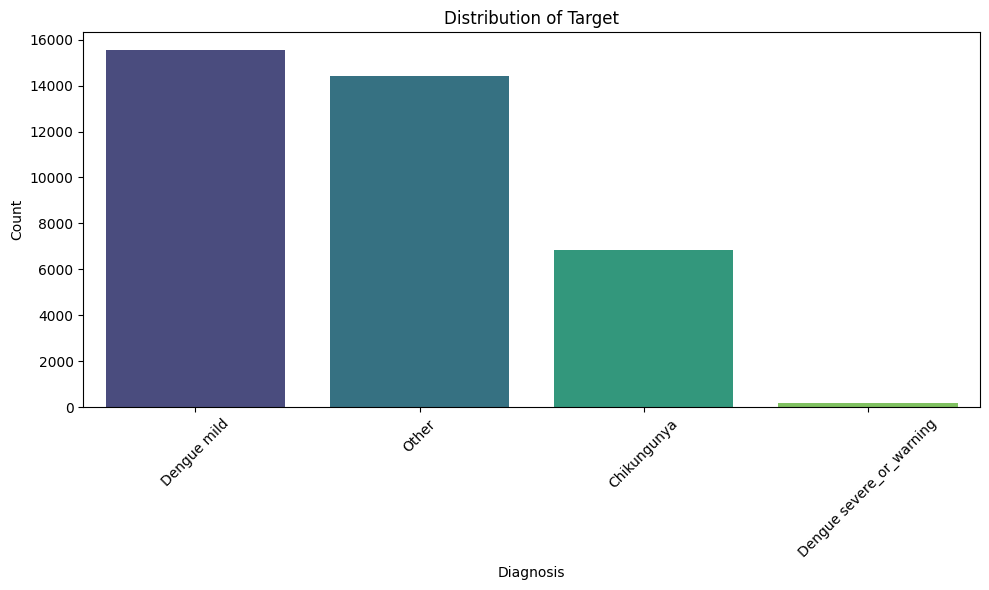

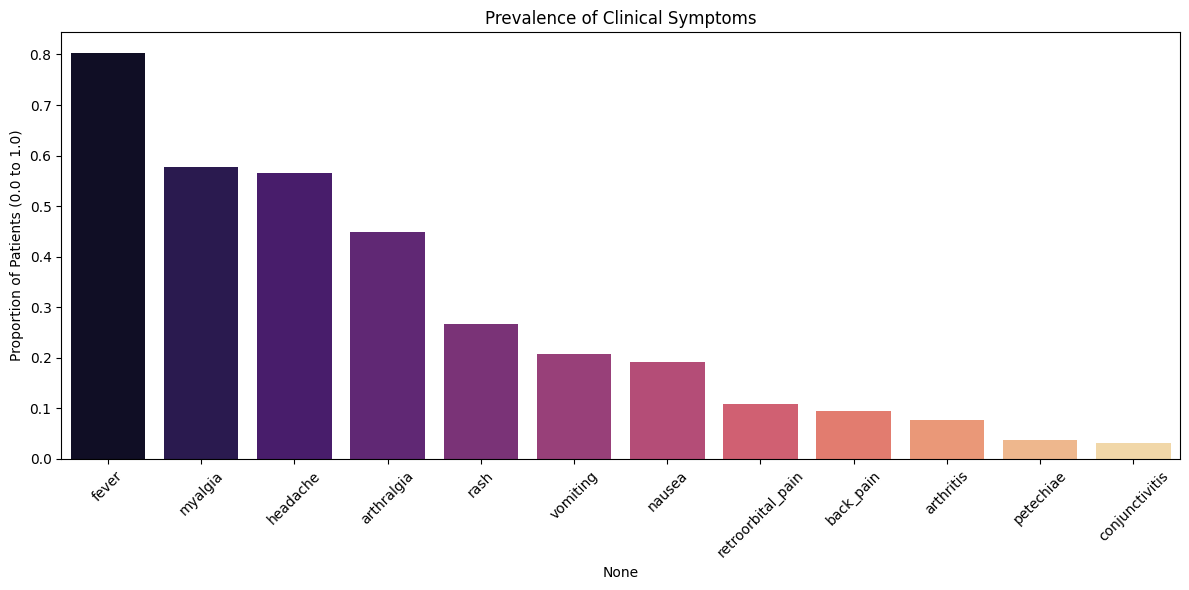

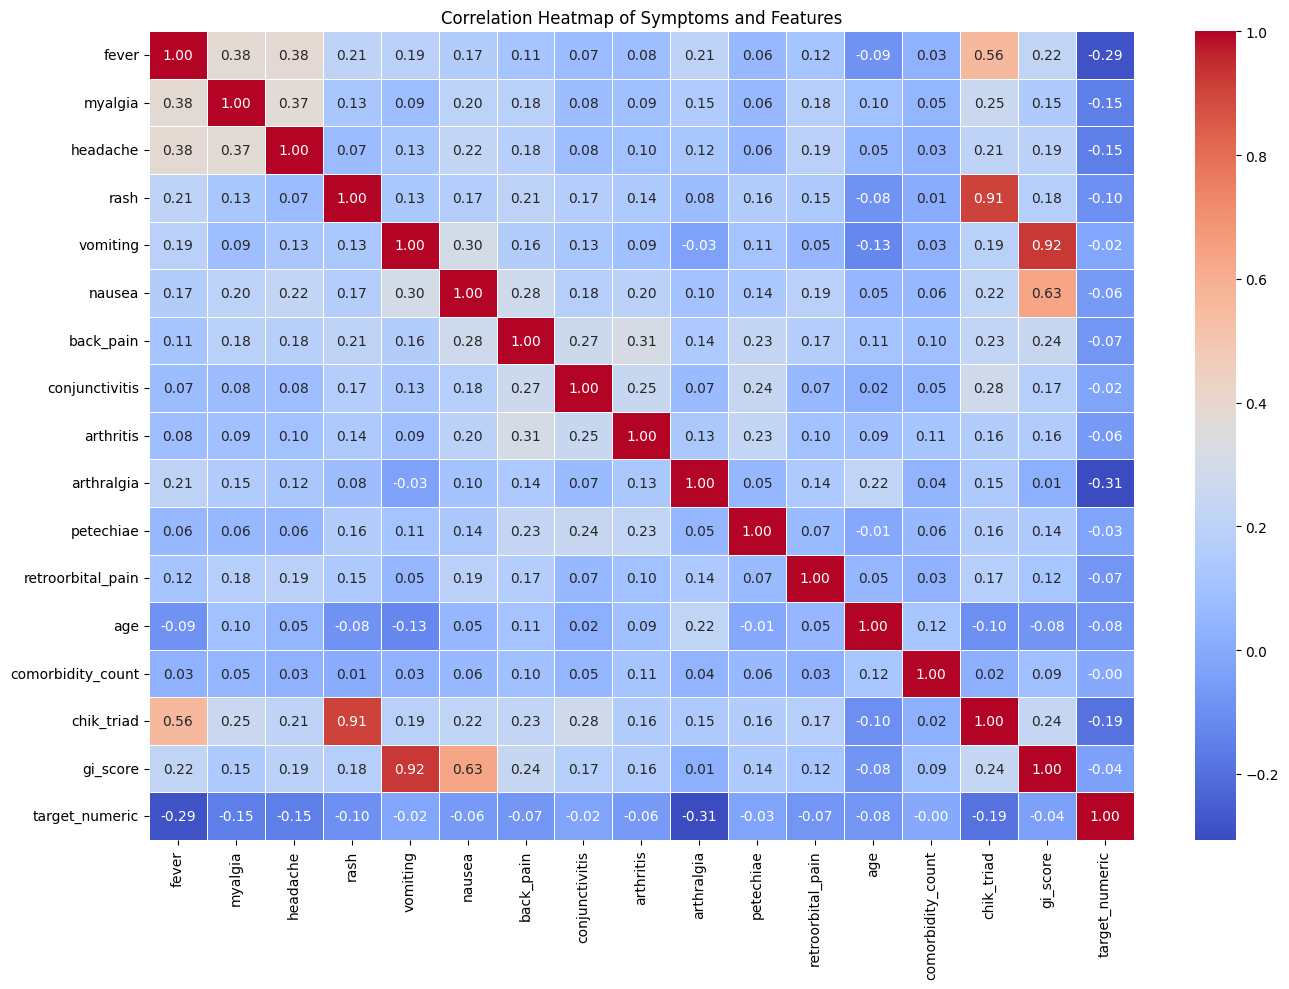

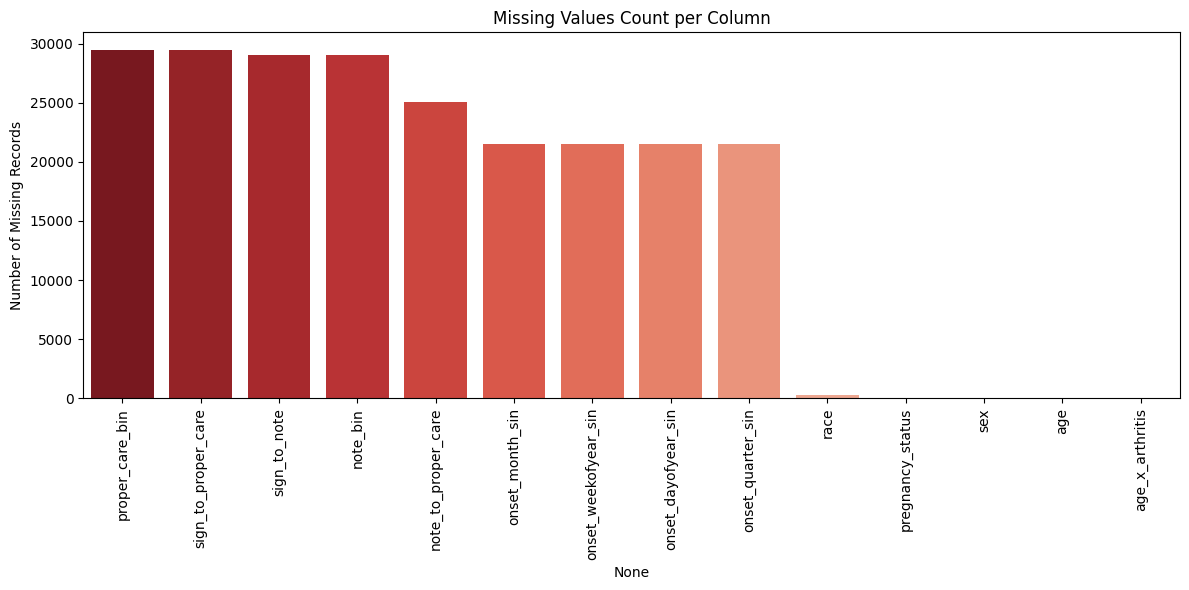

In [64]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='target', order=df['target'].value_counts().index, palette='viridis')
plt.title('Distribution of Target')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

# Calculate mean (proportion) for each symptom
symptom_means = df[SYMPTOM_FEATURES].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=symptom_means.index, y=symptom_means.values, palette='magma')
plt.title('Prevalence of Clinical Symptoms')
plt.ylabel('Proportion of Patients (0.0 to 1.0)')
plt.xticks(rotation=45)
plt.tight_layout()

# Correlation Heatmap (between symptoms and target)
df['target_numeric'] = df['target'].astype('category').cat.codes

corr_features = SYMPTOM_FEATURES + ['age', 'comorbidity_count', 'chik_triad', 'gi_score', 'target_numeric']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Symptoms and Features')
plt.tight_layout()

# 8. Visualizing Missing Data
plt.figure(figsize=(12, 6))
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if not missing_data.empty:
    sns.barplot(x=missing_data.index, y=missing_data.values, palette='Reds_r')
    plt.title('Missing Values Count per Column')
    plt.xticks(rotation=90)
    plt.ylabel('Number of Missing Records')
    plt.tight_layout()
    plt.savefig('missing_values.png')

In [65]:
df["target"]

0              Other
1        Dengue mild
2              Other
3        Dengue mild
4        Dengue mild
            ...     
36994    Chikungunya
36995          Other
36996    Chikungunya
36997    Chikungunya
36998    Chikungunya
Name: target, Length: 36999, dtype: string